In [1]:
from classy import Class

import os
import copy
import yaml
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

from matplotlib import rc
from scipy.interpolate import interp1d

rc('font',**{'family':'serif','serif':['Times']})
rc('text', usetex=True)
#matplotlib.rc('font', **font)
matplotlib.rcParams['legend.fontsize']='medium'
plt.rcParams["figure.figsize"] = [8.0,6.0]

# warmup

run a fiducial cosmology

In [2]:
params_EDE = {

    "output": "tCl,lCl,mPk",
    # LCDM parameters
    "omega_b": 0.02251,
    "omega_cdm": 0.1320,
    "H0": 72.81,
    "tau_reio": 0.068,
    "A_s": 2.191e-9,
    "n_s": 0.9860,

    # neutrinos
    "N_ur": 2.0328,
    "N_ncdm": 1,
    "deg_ncdm": 1,
    "m_ncdm": 0.06,
    "T_ncdm": 0.71611,

    # EDE parameters
    "scf_potential": "axion",
    "n_axion": 2.6,
    "f_axion": 0.1,
    "m_axion": 1e4,
    "scf_parameters": '2.72,0',

    # extra EDE parameters
    "scf_evolve_as_fluid": "no",
    "scf_evolve_like_axionCAMB": "no",
    "do_shooting": "no",
    "do_shooting_scf": "no",
    "attractor_ic_scf": "no",

    # verbosity
    "input_verbose": 1,
    "background_verbose": 1,
    "thermodynamics_verbose": 1,
    "perturbations_verbose": 1,
    "transfer_verbose": 1,
    "primordial_verbose": 1,
    #"spectra_verbose": 1,
    # "nonlinear_verbose": 1,
    "lensing_verbose": 1,
    "output_verbose": 1,
    "l_max_scalars":5000,
}


In [3]:
params_mEDE = {
    # "compute_sigma8": "yes",

    "output": "tCl,lCl,mPk",
    "omega_b": 0.02251,
    "omega_cdm": 0.1320,
    "H0": 72.81,
    "tau_reio": 0.068,
    "A_s": 2.191e-9,
    "n_s": 0.9860,

    "N_ur": 2.0328,
    "N_ncdm": 1,
    "deg_ncdm": 1,
    "m_ncdm": 0.06,
    "T_ncdm": 0.7161,

    "N_mscf": 1,
    "n_axion_mscf": 2.6,
    "f_axion_mscf": 0.1,
    "m_mscf": 1e4, 
    "theta_ini_mscf": 2.72,
    "theta_prime_ini_mscf": 0.0,

    "input_verbose": 1,
    "background_verbose": 1,
    "thermodynamics_verbose": 1,
    "perturbations_verbose": 1,
    "transfer_verbose": 1,
    "primordial_verbose": 1,
    # "spectra_verbose": 1,
    # "nonlinear_verbose": 1,
    "lensing_verbose": 1,
    "output_verbose": 1,
    "l_max_scalars":5000,
}


In [4]:
EDE1 = Class()
EDEm = Class()
EDE1.set(params_EDE)
EDEm.set(params_mEDE)

True

In [5]:
#LCDM.compute()
EDE1.compute()
EDEm.compute()

#ADE1.get_background()
#ADE2.get_background()

Reading input parameters
Reading input parameters
exited input find root
alpha_squared -3.000000e+01
power_of_mu -3.000000e+01
 -> matched budget equations by adjusting Omega_Lambda = 0.70726
Running CLASS version v3.3.0
Computing background
 -> non-cold dark matter species with i=1 has m_i = 6.000000e-02 eV (so m_i / omega_i =9.313858e+01 eV)
 -> non-cold dark matter species with i=1 has m_i = 6.000000e-02 eV (so m_i / omega_i =9.313858e+01 eV)
 -> ncdm species i=1 sampled with 11 (resp. 5) points for purpose of background (resp. perturbation) integration. In the relativistic limit it gives Delta N_eff = 1.0132
shouldnt enter here with mscf and no scf adjusted Omega_Lambda to incorporate the axion contribution; new Omega_Lambda = 7.072569e-01  
shouldnt enter here with mscf and no scf adjusted Omega_Lambda to incorporate the axion contribution; new Omega_Lambda = 7.072569e-01  
 -> age = 13.032250 Gyr
 -> conformal age = 13493.666196 Mpc
 -> H0 = 72.810000 km/s/Mpc
 -> N_eff = 3.046 (

In [6]:
bg1 = EDE1.get_background()
print(bg1.keys())
bg_m = EDEm.get_background()
print(bg_m.keys())
derived = EDE1.get_current_derived_parameters(['z_eq','z_rec'])

dict_keys(['z', 'proper time [Gyr]', 'conf. time [Mpc]', 'H [1/Mpc]', 'comov. dist.', 'ang.diam.dist.', 'lum. dist.', 'comov.snd.hrz.', '(.)rho_g', '(.)rho_b', '(.)rho_cdm', '(.)rho_ncdm[0]', '(.)p_ncdm[0]', '(.)rho_lambda', '(.)rho_ur', '(.)rho_crit', '(.)rho_scf', '(.)Omega_scf', '(.)p_scf', '(.)p_prime_scf', '(.)w_scf', '(.)dw_scf', 'phi_scf', "phi'_scf", 'V_scf', "V'_scf", "V''_scf", '(.)rho_tot', '(.)p_tot', '(.)p_tot_prime', 'gr.fac. D', 'gr.fac. f'])
dict_keys(['z', 'proper time [Gyr]', 'conf. time [Mpc]', 'H [1/Mpc]', 'comov. dist.', 'ang.diam.dist.', 'lum. dist.', 'comov.snd.hrz.', '(.)rho_g', '(.)rho_b', '(.)rho_cdm', '(.)rho_ncdm[0]', '(.)p_ncdm[0]', '(.)rho_lambda', '(.)rho_ur', '(.)rho_crit', '(.)rho_mscf[0]', '(.)Omega_mscf[0]', '(.)p_mscf[0]', '(.)p_prime_mscf[0]', '(.)w_mscf[0]', 'phi_mscf[0]', "phi'_mscf[0]", 'V_mscf[0]', "V'_mscf[0]", "V''_mscf[0]", '(.)rho_tot', '(.)p_tot', '(.)p_tot_prime', 'gr.fac. D', 'gr.fac. f'])


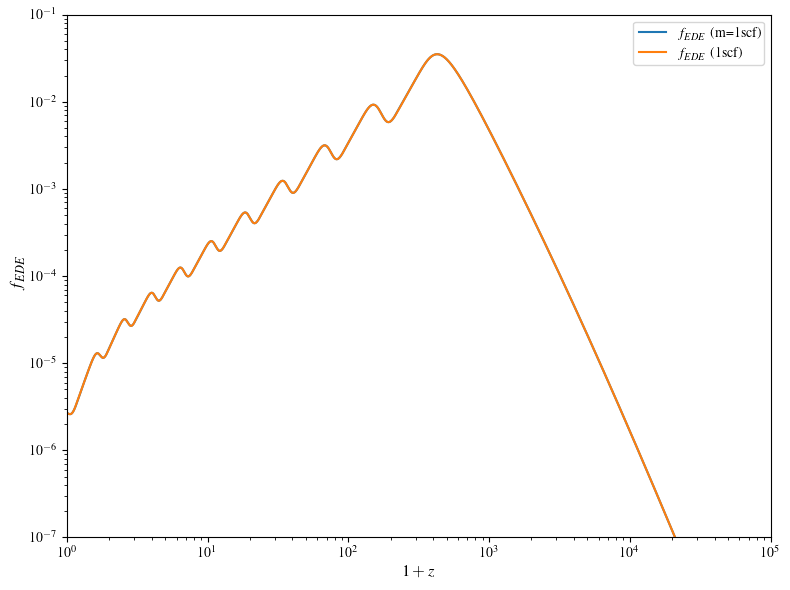

In [7]:
# Prepare the data
z = bg_m['z']
z1 = bg1['z']

fig, ax = plt.subplots()
for i in range(params_mEDE['N_mscf']):  # Corrected to use params_mEDE
    rho_EDE_m = bg_m[f'(.)rho_mscf[{i}]']
    f_EDE_m = rho_EDE_m / bg_m['(.)rho_tot']
    ax.plot(1+z, f_EDE_m, label=f'$f_{{EDE}}$ (m=1scf)')
rho_EDE_1 = bg1[f'(.)rho_scf']
f_EDE_1 = rho_EDE_1 / bg1['(.)rho_tot']
ax.plot(1+z1, f_EDE_1, label=f'$f_{{EDE}}$ (1scf)')
    
ax.set_xlabel(r'$1+z$',fontsize='large')
ax.set_ylabel(r'$f_{EDE}$',fontsize='large')
#ax.set_ylim(0, .1)  # Set based on physical expectations
#ax.tick_params(colors='darkred')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper right', bbox_to_anchor=(1, 1))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e0,1e5)
ax.set_ylim(1e-7,1e-1)

plt.tight_layout()
plt.show()

# Compute $C_l$ 

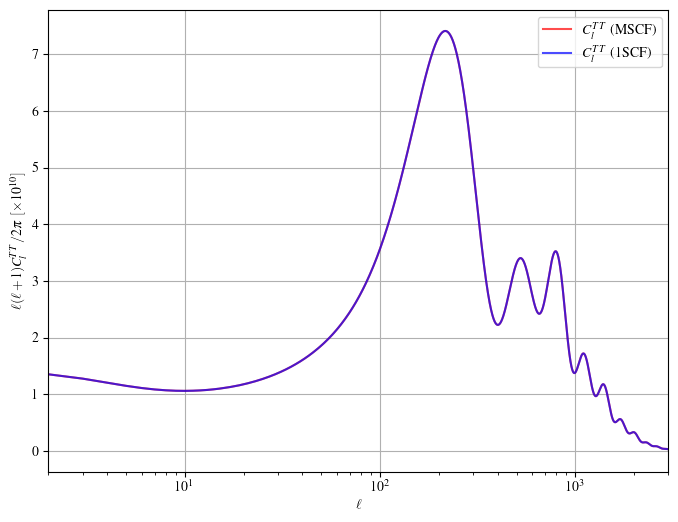

In [8]:
fig, ax = plt.subplots()
plt.xlim([2,3000])
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell (\ell+1) C_l^{TT} / 2 \pi \,\,\, [\times 10^{10}]$")
plt.grid()
pi = np.pi#

cl_tot = EDEm.raw_cl(3000)
cl_tot_1 = EDE1.raw_cl(3000)
# cl_lensed = EDEm.lensed_cl(3000)
ell = cl_tot['ell']
ell_1 = cl_tot_1['ell']
factor = 1.e10*ell*(ell+1.)/2./pi
factor1 = 1.e10*ell_1*(ell_1+1.)/2./pi
plt.semilogx(ell,factor*cl_tot['tt'],'r-',label=r'$C_l^{TT}$ (MSCF)',alpha=0.7)
plt.semilogx(ell,factor1*cl_tot_1['tt'],'b-',label=r'$C_l^{TT}$ (1SCF)',alpha=0.7)

plt.legend()
    

/var/folders/ds/l5tt9lyx5pl1c9t1ytlzxb7w0000gn/T/ipykernel_6830/398706777.py:3: RuntimeWarning: invalid value encountered in divide
  plt.plot(ell,(factor*cl_tot['tt']-factor1*cl_tot_1['tt'])/(factor*cl_tot['tt']),'r-',label='TT residuals')


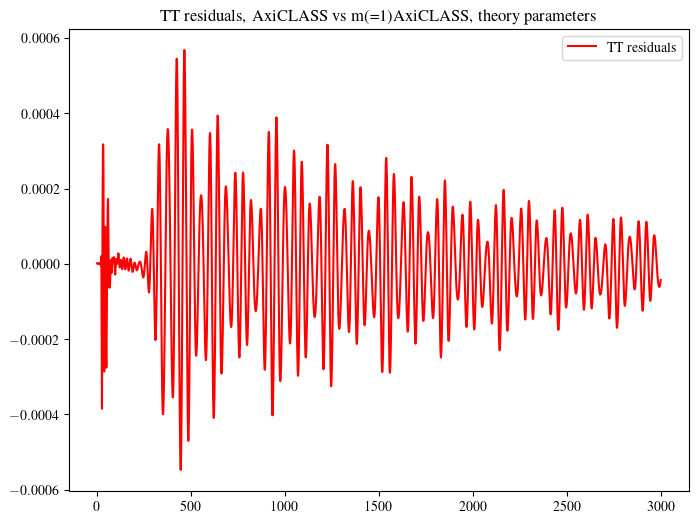

In [17]:
plt.title('TT residuals, AxiCLASS vs m(=1)AxiCLASS, theory parameters')

plt.plot(ell,(factor*cl_tot['tt']-factor1*cl_tot_1['tt'])/(factor*cl_tot['tt']),'r-',label='TT residuals')
plt.legend()

# Matter power spectrum

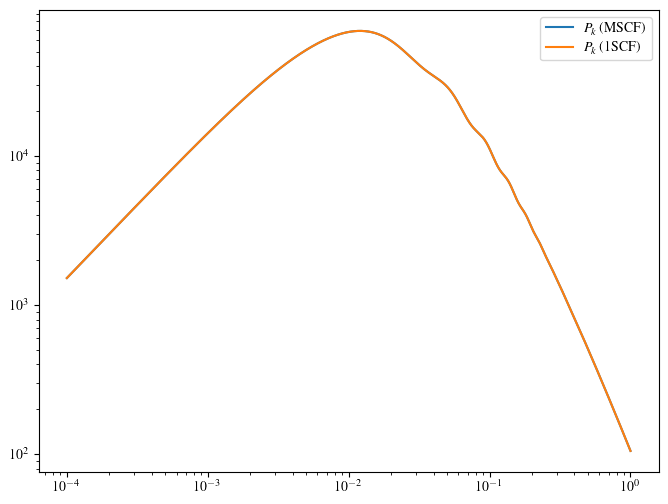

In [10]:
kk = np.logspace(-4, 0, 10000)
Pk_axion1 = [EDE1.pk(ki, 0) for ki in kk]

Pk_axion_m = [EDEm.pk(ki, 0) for ki in kk]

fig, ax = plt.subplots()
plt.plot(kk,Pk_axion1,label=r'$P_k$ (MSCF)')
plt.plot(kk,Pk_axion_m,label=r'$P_k$ (1SCF)')
ax.set_xscale('log')
ax.set_yscale('log')
plt.legend()


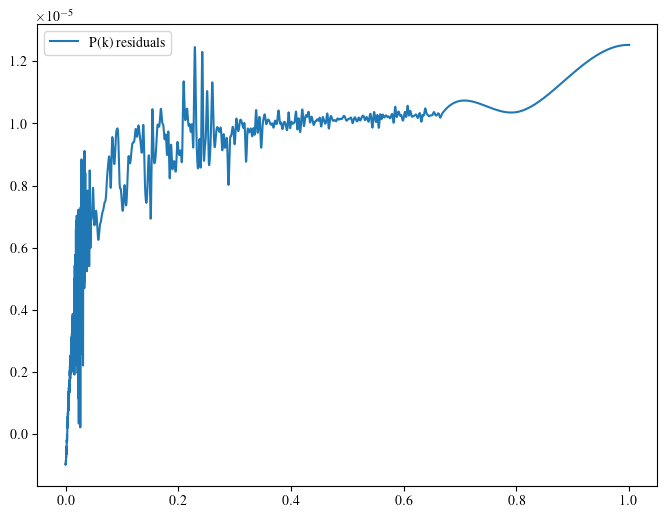

In [15]:
plt.title('P(k) residuals, AxiCLASS vs m(=1)AxiCLASS, theory parameters')
plt.plot(kk,(np.array(Pk_axion_m)-np.array(Pk_axion1))/np.array(Pk_axion1),label='P(k) residuals')
plt.legend()

In [12]:
# EDE1.empty()
# EDEm.empty()